# Edge IIoT - Binary Classification (Experiment 2 — Feature Selection)

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from src.config import DATASETS, SEED
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['processed_path']}\n")

filename = "ML-EdgeIIoT-dataset"

csv_path = config['processed_path'] / f"{filename}.pkl"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_pickle(csv_path)

print(f"\nDataset loaded with shape: {df.shape}")


--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed/ML-EdgeIIoT-dataset.pkl

Loading dataset... (This may take a while)

Dataset loaded with shape: (152590, 62)


## 1. Pre-processing

In [3]:
df_naive = df.select_dtypes(include=['number'])

target = 'Attack_label'
X = df_naive.drop(columns=[target])
y = df_naive[target]

Y_str = df['Attack_type'] # Used to stratify later

In [4]:
categorical_cols = X.select_dtypes(include=['str', 'object', 'category']).columns
print(f"Check for categorical columns: {list(categorical_cols)}", "\t(Should only include 'Attack_type')")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Check for categorical columns: [] 	(Should only include 'Attack_type')


In [5]:
X.columns

Index(['arp.opcode_reply', 'arp.opcode_request', 'dns.retransmission',
       'dns.retransmit_request', 'dns.retransmit_request_in',
       'frame.time.delta', 'frame.time.order', 'frame.time.valid',
       'http.content_length', 'http.request.method_get',
       'http.request.method_options', 'http.request.method_post',
       'http.request.method_propfind', 'http.request.method_put',
       'http.request.method_search', 'http.request.method_trace',
       'http.response', 'http.tls_port', 'icmp.seq_le',
       'ip.dst_category_Malformed', 'ip.dst_category_Private',
       'ip.dst_category_Public', 'ip.dst_category_Reserved',
       'ip.src_category_Malformed', 'ip.src_category_Private',
       'ip.src_category_Public', 'ip.src_category_Reserved', 'mbtcp.len',
       'mbtcp.trans_id', 'mbtcp.unit_id', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.len', 'mqtt.msgtype_connack',
       'mqtt.msgtype_connect', 'mqtt.msgtype_disconnect',
       'mqtt.msgtype_publish', 'tcp.ac

In [6]:
cols_to_drop = [
    'frame.time.delta', 'frame.time.order',
    *[c for c in X.columns if c.startswith('ip.src_category') or c.startswith('ip.dst_category')]
]
X = X.drop(columns=cols_to_drop, errors='ignore')

In [7]:
print(f"\nFinal feature set shape after encoding: {X.shape}")
print(f"NaN values in target variable: {y.isna().sum()}")
print(f"NaN values in features: {X.isna().sum().sum()}")


Final feature set shape after encoding: (152590, 43)
NaN values in target variable: 0
NaN values in features: 0


In [8]:
X_train, X_test, y_train, y_test, Y_str_train, Y_str_test = train_test_split(
    X, y, Y_str, test_size=0.2, random_state=SEED, stratify=Y_str
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_results = {}

X_train shape: (122072, 43)
X_test shape: (30518, 43)


## 2. Model Tuning: ExtraTreesClassifier
Train and tune a ExtraTreesClassifier using RandomizedSearchCV.

In [9]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("Setting up RandomizedSearchCV for ExtraTreesClassifier...")

# Baseline model
rf_base = ExtraTreesClassifier(
    random_state=SEED,
    n_jobs=-1,
)

# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300],         # Number of trees in the forest. More trees reduce variance.
    'max_depth': [None, 10, 20, 30],             # Maximum depth of the trees.
    'min_samples_split': [2, 5, 10],             # Minimum number of samples required to split an internal node.
    'min_samples_leaf': [1, 2, 4],               # Minimum number of samples required to be at a leaf node.
    'max_features': ['sqrt', 'log2', None]       # Number of features to consider when looking for the best split.
}

# Setup randomized search (n_iter=10 means it will randomly try 10 combinations)
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1,
    scoring='f1_weighted'
)

start_time = time.time()
print("Starting hyperparameter tuning... (This might take a few minutes)")
rf_random.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {train_time:.2f} seconds.")
print(f"Best parameters found:\n{rf_random.best_params_}")

# Override rf_clf with the best model
rf_clf = rf_random.best_estimator_

Setting up RandomizedSearchCV for ExtraTreesClassifier...
Starting hyperparameter tuning... (This might take a few minutes)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   8.6s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=  11.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  11.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=  13.6s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  13.5s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  13.2s
[CV] END max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50

## 3. Evaluation
Evaluate the model's performance on the test set.

Evaluating model on test data...

--- Overall Metrics ---
Accuracy: 0.974769
ROC AUC Score: 0.992542

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      4860
           1       0.97      1.00      0.99     25658

    accuracy                           0.97     30518
   macro avg       0.99      0.92      0.95     30518
weighted avg       0.98      0.97      0.97     30518



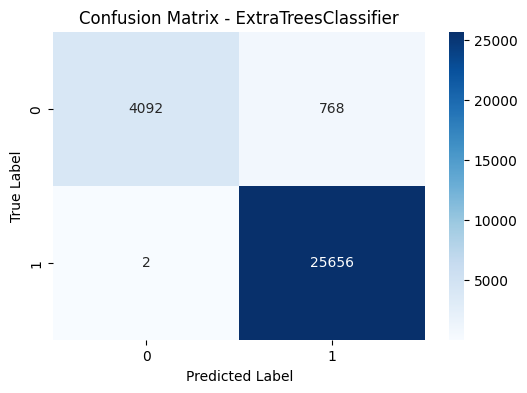

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

print("Evaluating model on test data...")
y_pred = rf_clf.predict(X_test_scaled)
y_prob = rf_clf.predict_proba(X_test_scaled)[:, 1] if hasattr(rf_clf, "predict_proba") else y_pred

print("\n--- Overall Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.6f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.6f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ExtraTreesClassifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 4. Feature Importance
Visualize the top features driving the predictions.

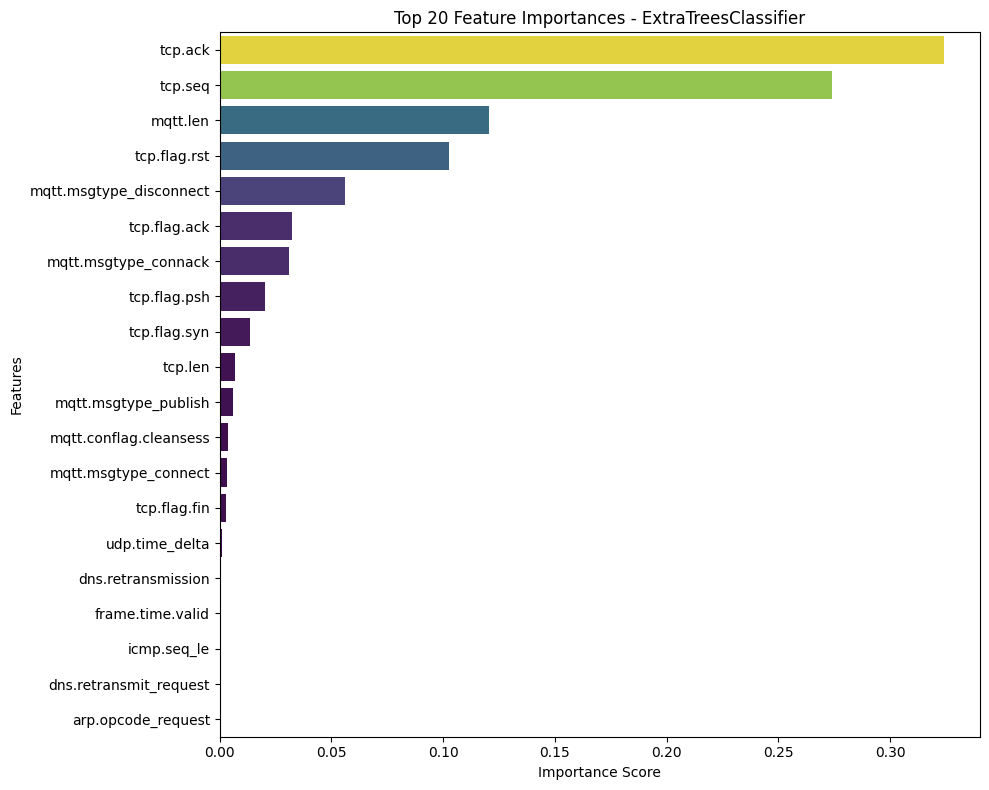

In [11]:
feature_names = X.columns
importances = rf_clf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Importance', data=fi_df, palette='viridis', legend=False)
plt.title('Top 20 Feature Importances - ExtraTreesClassifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 5. Explainable AI (SHAP)
Understand how the model makes its decisions using SHAP (SHapley Additive exPlanations).

In [12]:
import shap
shap.initjs()

# Sample size
n_sample = 5000
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Stratified sampling
if X_test_scaled_df.shape[0] > n_sample:
    X_sample, _, y_sample, _ = train_test_split(
        X_test_scaled_df,
        y_test,
        train_size=n_sample,
        random_state=SEED,
        stratify=y_test
    )
else:
    X_sample = X_test_scaled_df.copy()
    y_sample = y_test.copy()

print(f"Extracted {X_sample.shape[0]} stratified observations for SHAP calculation.")
print(f"Class distribution in SHAP sample:\n{y_sample.value_counts(normalize=True).to_string()}")

Extracted 5000 stratified observations for SHAP calculation.
Class distribution in SHAP sample:
Attack_label
1    0.8408
0    0.1592


In [13]:
explainer = shap.TreeExplainer(rf_clf)
shap_obj = explainer(X_sample)

# Handle the output dimensionality depending on objective function (binary vs multiclass)
if len(shap_obj.shape) == 3:
    plot_obj = shap_obj[:, :, 1] # Extract positive class for binary classification
else:
    plot_obj = shap_obj

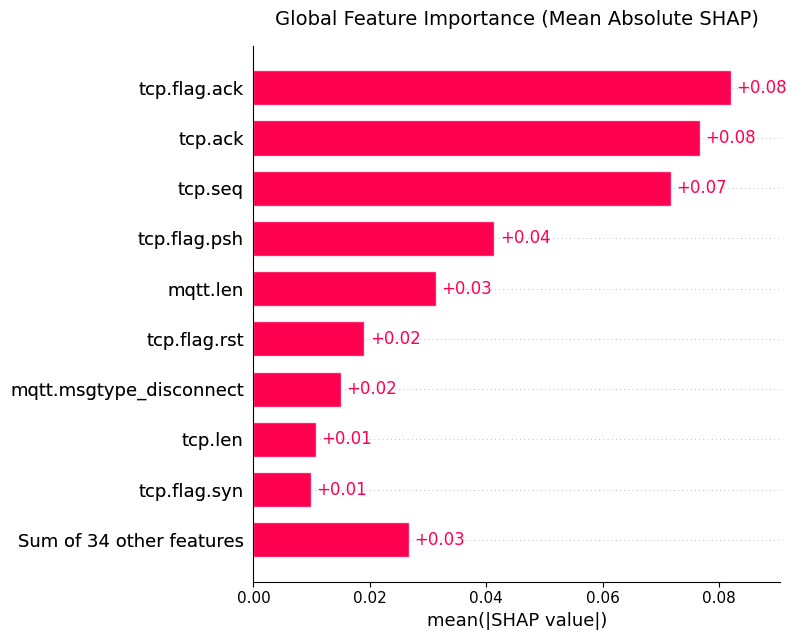

In [14]:
# Plot 1: Global Bar Plot (Mean Absolute SHAP)
plt.figure(figsize=(16, 6))
shap.plots.bar(plot_obj, max_display=10, show=False)
plt.title("Global Feature Importance (Mean Absolute SHAP)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

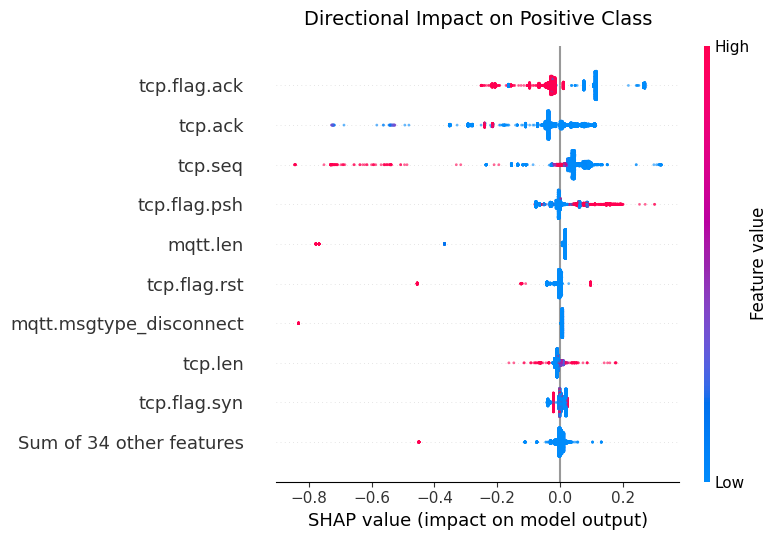

In [15]:
# Plot 2: Beeswarm Plot (Directional Impact)
plt.figure(figsize=(16, 6))
shap.plots.beeswarm(
    plot_obj,
    max_display=10,
    s=4,
    alpha=0.6,
    show=False
)
plt.title("Directional Impact on Positive Class", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 6. Save Model
Save the trained model and scaler for reproducibility and results aggregation.

In [16]:
import joblib

model_path = config['bin_model_path'] / 'exp2'
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_clf, model_path / 'model_et.pkl')
joblib.dump(scaler, model_path / 'scaler_et.pkl')

print(f"Model saved to:  {model_path / 'model_et.pkl'}")
print(f"Scaler saved to: {model_path / 'scaler_et.pkl'}")

Model saved to:  /home/uo294319/ML-NIDS-IIoT/models/edge_iiot/binary/exp2/model_et.pkl
Scaler saved to: /home/uo294319/ML-NIDS-IIoT/models/edge_iiot/binary/exp2/scaler_et.pkl
